In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Sales.csv")

In [3]:
df

,Date,Time,State,Group,Unit,Sales
0,01-Oct-20,Morning,WA,Kids,8,20000
1,01-Oct-20,Morning,WA,Men,8,20000
2,01-Oct-20,Morning,WA,Women,4,10000
3,01-Oct-20,Morning,WA,Seniors,15,37500
4,01-Oct-20,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,30-Dec-20,Afternoon,TX,Seniors,14,35000
7556,30-Dec-20,Evening,TX,Kids,15,37500
7557,30-Dec-20,Evening,TX,Men,15,37500
7558,30-Dec-20,Evening,TX,Women,11,27500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [5]:
df.shape

(7560, 6)

In [6]:
# Check for missing value
df.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

In [7]:
#verify that no missing values
df.notnull().sum()

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64

In [8]:
df.isnull().values.any()

np.False_

In [9]:
# creating df for only numeric values
df_dataonly= df[["Unit", "Sales"]]

In [10]:
df_dataonly.head()

,Unit,Sales
0,8,20000
1,8,20000
2,4,10000
3,15,37500
4,3,7500


In [11]:
# create a Normalizer object
from sklearn.preprocessing import MinMaxScaler
normalizer = MinMaxScaler()

In [12]:
normalized_data= normalizer.fit_transform(df_dataonly)

In [13]:
normalized_data

array([[0.0952381 , 0.0952381 ],
       [0.0952381 , 0.0952381 ],
       [0.03174603, 0.03174603],
       ...,
       [0.20634921, 0.20634921],
       [0.14285714, 0.14285714],
       [0.17460317, 0.17460317]])

In [14]:
normalized_data.shape

(7560, 2)

In [15]:
normalized_df=pd.DataFrame(normalized_data, columns=["Unit_normalized", "Sales_normalized"])

In [16]:
normalized_df.head()

,Unit_normalized,Sales_normalized
0,0.095238,0.095238
1,0.095238,0.095238
2,0.031746,0.031746
3,0.206349,0.206349
4,0.015873,0.015873


In [17]:
normalized_df.min(), normalized_df.max()

(Unit_normalized     0.0
 Sales_normalized    0.0
 dtype: float64,
 Unit_normalized     1.0
 Sales_normalized    1.0
 dtype: float64)

In [18]:
# convert date column to datetime format
df["Date"]=pd.to_datetime(df["Date"])

C:\Users\user\AppData\Local\Temp\ipykernel_10476\1248731340.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"]=pd.to_datetime(df["Date"])


In [19]:
df['Date'].dtype

dtype('<M8[ns]')

In [20]:
#Group Data by Date

daily_data= df.groupby("Date")[["Unit","Sales"]].sum().reset_index()
daily_data.head()

,Date,Unit,Sales
0,2020-10-01,1488,3720000
1,2020-10-02,1486,3715000
2,2020-10-03,1556,3890000
3,2020-10-04,1488,3720000
4,2020-10-05,1545,3862500


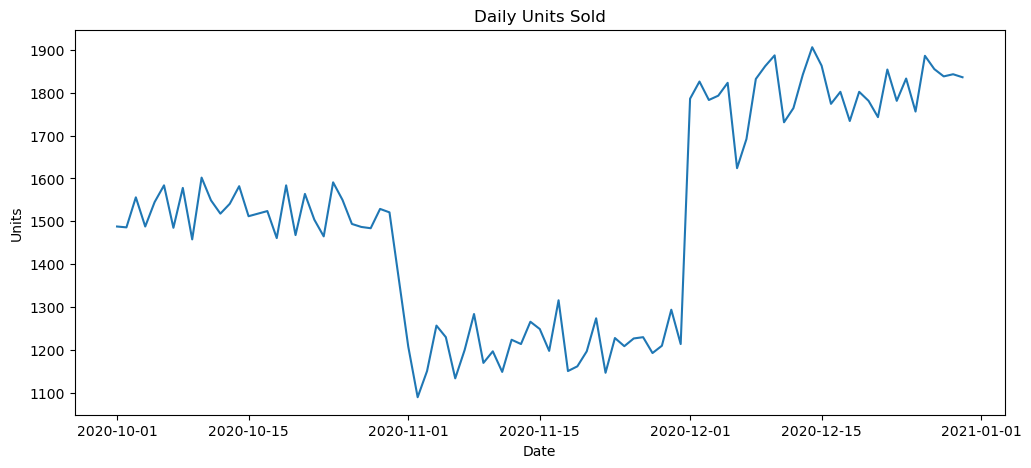

In [21]:
# Plot Date vs Unit
plt.figure(figsize=(12,5))
plt.plot(daily_data["Date"], daily_data['Unit'])
plt.title("Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units")
plt.show()

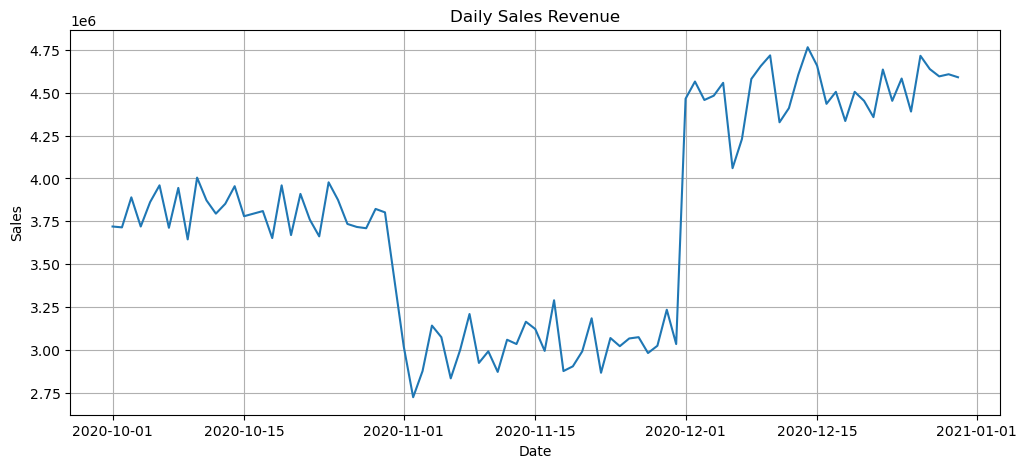

In [22]:
# Plot Date vs Sales
plt.figure(figsize=(12, 5))
plt.plot(daily_data['Date'], daily_data['Sales'])
plt.title('Daily Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [23]:
# creating new column of Month
df["Month"]=df["Date"].dt.month_name()

In [24]:
df

,Date,Time,State,Group,Unit,Sales,Month
0,2020-10-01,Morning,WA,Kids,8,20000,October
1,2020-10-01,Morning,WA,Men,8,20000,October
2,2020-10-01,Morning,WA,Women,4,10000,October
3,2020-10-01,Morning,WA,Seniors,15,37500,October
4,2020-10-01,Afternoon,WA,Kids,3,7500,October
...,...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TX,Seniors,14,35000,December
7556,2020-12-30,Evening,TX,Kids,15,37500,December
7557,2020-12-30,Evening,TX,Men,15,37500,December
7558,2020-12-30,Evening,TX,Women,11,27500,December


In [25]:
df_oct=df.loc[df["Month"]=="October"]
df_nov=df.loc[df["Month"]=="November"]
df_dec=df.loc[df["Month"]=="December"]

In [26]:
df_oct["Date"].min(),df_oct["Date"].max()

(Timestamp('2020-10-01 00:00:00'), Timestamp('2020-10-30 00:00:00'))

In [27]:
df.describe()

,Date,Unit,Sales
count,7560,7560.000000,7560.000000
mean,2020-11-15 04:00:00.000000256,18.005423,45013.558201
min,2020-10-01 00:00:00,2.000000,5000.000000
25%,2020-10-23 00:00:00,8.000000,20000.000000
50%,2020-11-15 12:00:00,14.000000,35000.000000
75%,2020-12-08 00:00:00,26.000000,65000.000000
max,2020-12-30 00:00:00,65.000000,162500.000000
std,NaN,12.901403,32253.506944


In [28]:
df_oct.describe()

,Date,Unit,Sales
count,2520,2520.000000,2520.000000
mean,2020-10-15 12:00:00,18.141270,45353.174603
min,2020-10-01 00:00:00,3.000000,7500.000000
25%,2020-10-08 00:00:00,9.000000,22500.000000
50%,2020-10-15 12:00:00,14.000000,35000.000000
75%,2020-10-23 00:00:00,27.000000,67500.000000
max,2020-10-30 00:00:00,50.000000,125000.000000
std,NaN,11.944521,29861.302213


In [29]:
df_nov.describe()

,Date,Unit,Sales
count,2520,2520.000000,2520.000000
mean,2020-11-15 12:00:00,14.394048,35985.119048
min,2020-11-01 00:00:00,2.000000,5000.000000
25%,2020-11-08 00:00:00,6.000000,15000.000000
50%,2020-11-15 12:00:00,10.000000,25000.000000
75%,2020-11-23 00:00:00,22.000000,55000.000000
max,2020-11-30 00:00:00,45.000000,112500.000000
std,NaN,10.946470,27366.175823


In [30]:
df_dec.describe()

,Date,Unit,Sales
count,2520,2520.000000,2520.000000
mean,2020-12-15 12:00:00,21.480952,53702.380952
min,2020-12-01 00:00:00,5.000000,12500.000000
25%,2020-12-08 00:00:00,10.000000,25000.000000
50%,2020-12-15 12:00:00,15.000000,37500.000000
75%,2020-12-23 00:00:00,31.000000,77500.000000
max,2020-12-30 00:00:00,65.000000,162500.000000
std,NaN,14.554181,36385.451298


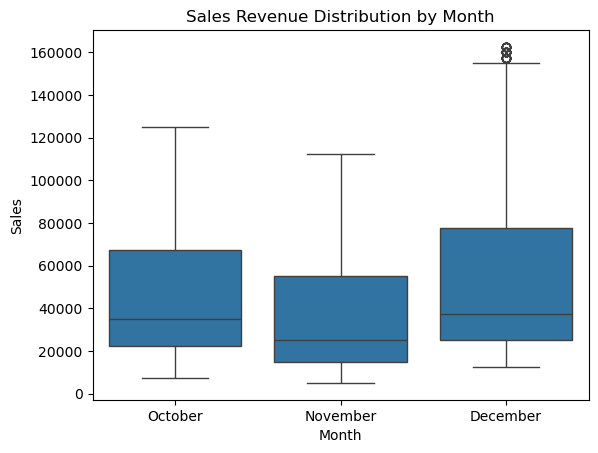

In [31]:
#Boxplot For Sales
sns.boxplot(x="Month",y="Sales", data=df)
plt.title("Sales Revenue Distribution by Month")
plt.show()

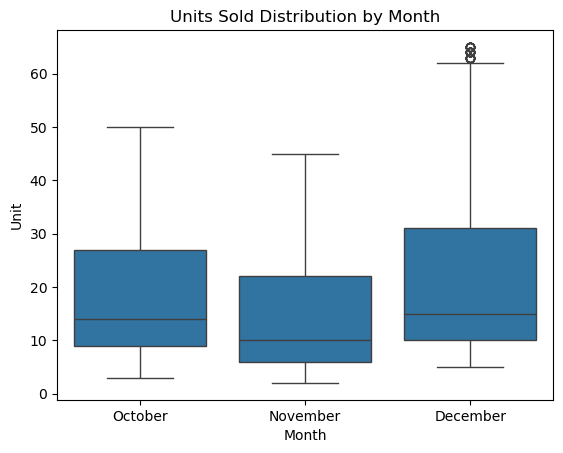

In [32]:
#Boxplot for Units
sns.boxplot(x="Month",y="Unit", data=df)
plt.title("Units Sold Distribution by Month")
plt.show()

In [33]:
# Overall Units and Sales (Bar Chart)
monthly_totals=df.groupby("Month")[["Unit","Sales"]].sum()



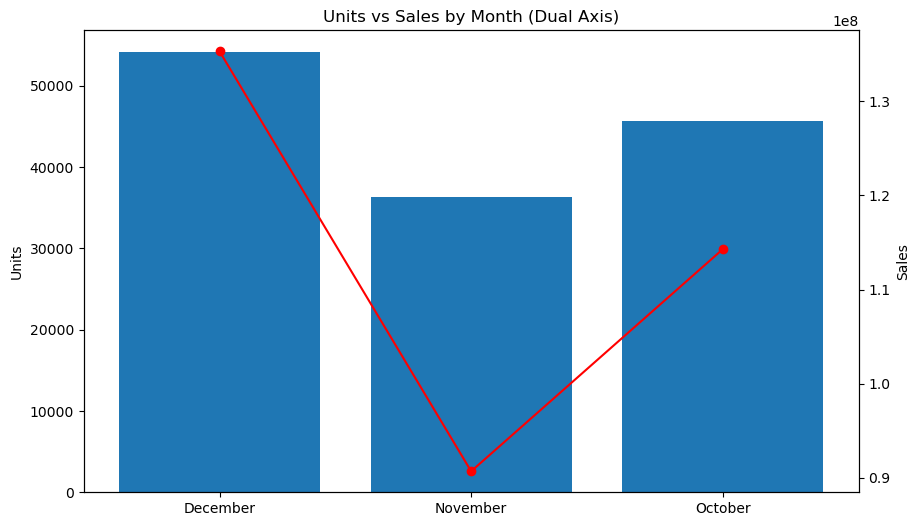

In [34]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(monthly_totals.index, monthly_totals["Unit"], label="Units")
ax1.set_ylabel("Units")
ax1.tick_params(axis="y")

ax2 = ax1.twinx()
ax2.plot(monthly_totals.index, monthly_totals["Sales"], label= "Sales", color="red", marker="o")
ax2.set_ylabel("Sales")
ax2.tick_params(axis="y")

plt.title("Units vs Sales by Month (Dual Axis)")
plt.show()

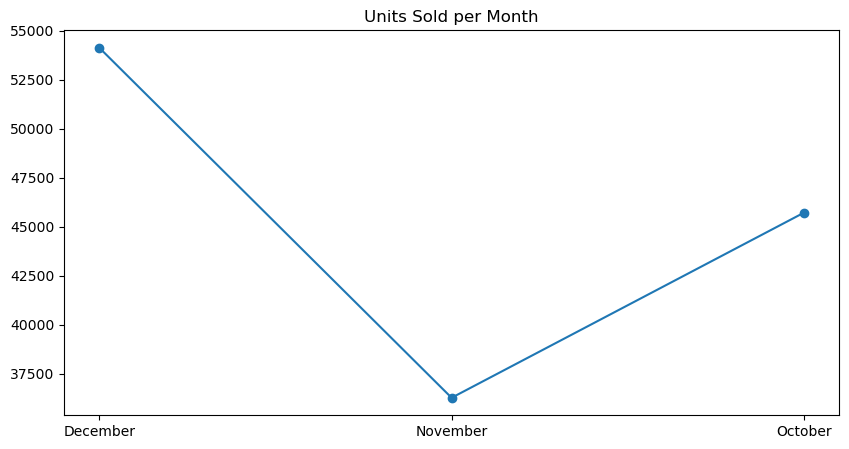

In [35]:
# Units Sold per Month (Line Plot)
plt.figure(figsize=(10,5))
plt.plot(monthly_totals.index, monthly_totals["Unit"], marker="o")
plt.title("Units Sold per Month")
plt.show()

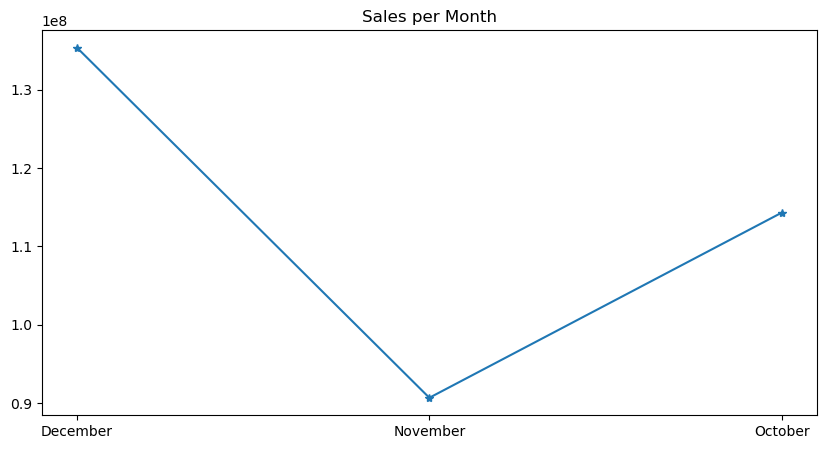

In [36]:
#Step 3: Sales per Month (Line Plot)
plt.figure(figsize=(10,5))
plt.plot(monthly_totals.index, monthly_totals["Sales"], marker="*")
plt.title("Sales per Month")
plt.show()

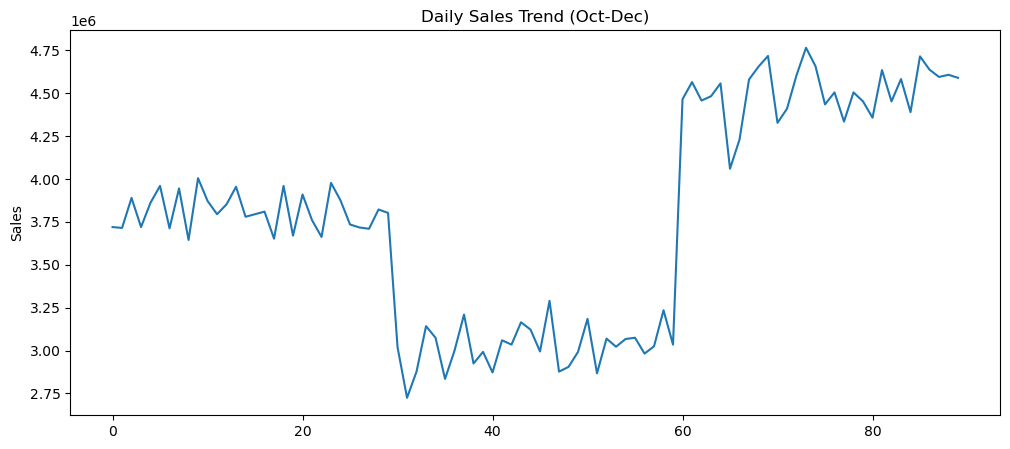

In [37]:
#Step 4: Consolidated 3-Month Sales Plot (Daily)
plt.figure(figsize=(12,5))
plt.plot(daily_data.index, daily_data["Sales"])
plt.title("Daily Sales Trend (Oct-Dec)")
plt.ylabel("Sales")
plt.show()

In [38]:
#Action 8

In [39]:
#Step 1: State-wise Analysis

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales.head()

State
KY    105565000
NY     74970000
FL     58857500
CA     33417500
TX     22760000
Name: Sales, dtype: int64

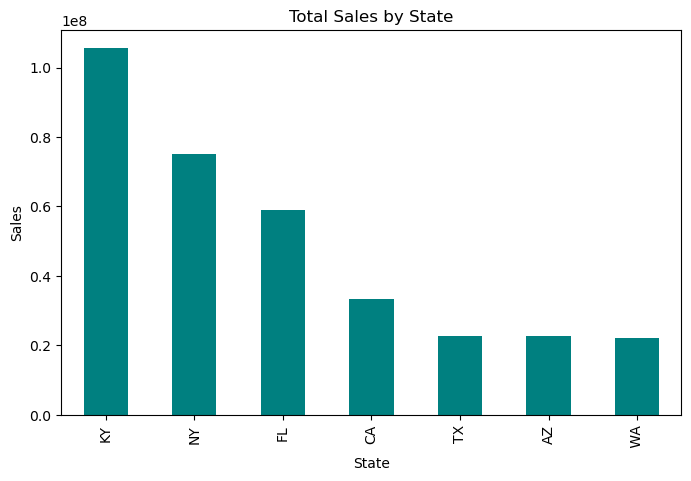

In [40]:
plt.figure(figsize=(8,5))
state_sales.plot(kind="bar", color="teal")
plt.title("Total Sales by State")
plt.ylabel("Sales")
plt.show()

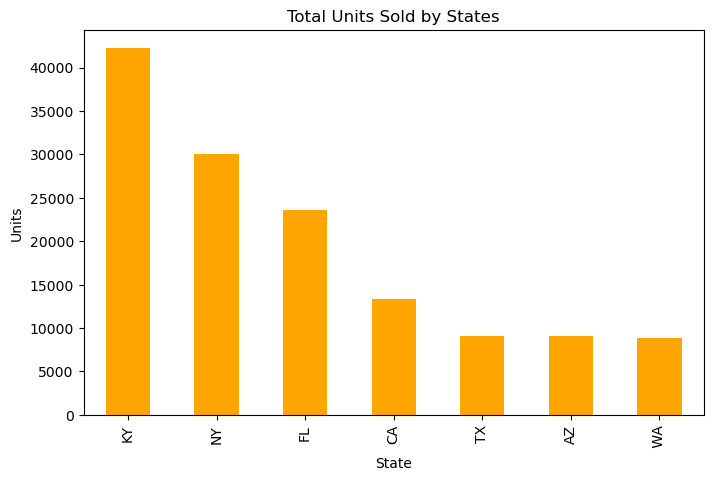

In [41]:
state_units = df.groupby("State")["Unit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
state_units.plot(kind="bar", color = "orange")
plt.title("Total Units Sold by States")
plt.ylabel("Units")
plt.show()

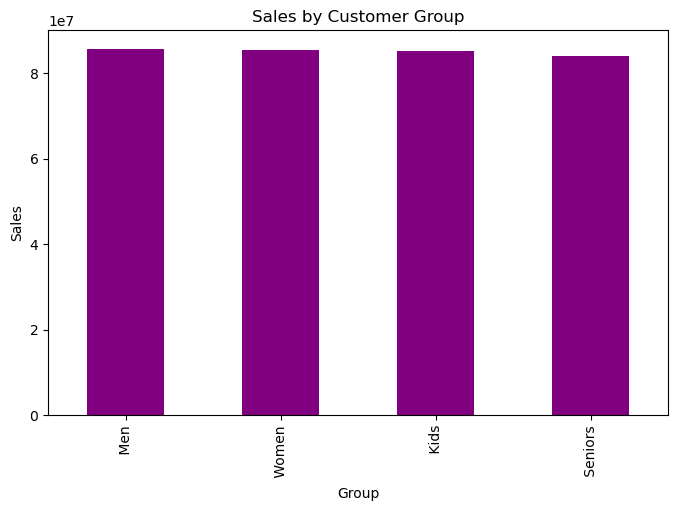

In [42]:
#Step 2: Group-wise Analysis(Men, Women, Kids, Seniors)

group_sales = df.groupby("Group")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
group_sales.plot(kind="bar", color= "purple")
plt.title("Sales by Customer Group")
plt.ylabel("Sales")
plt.show()

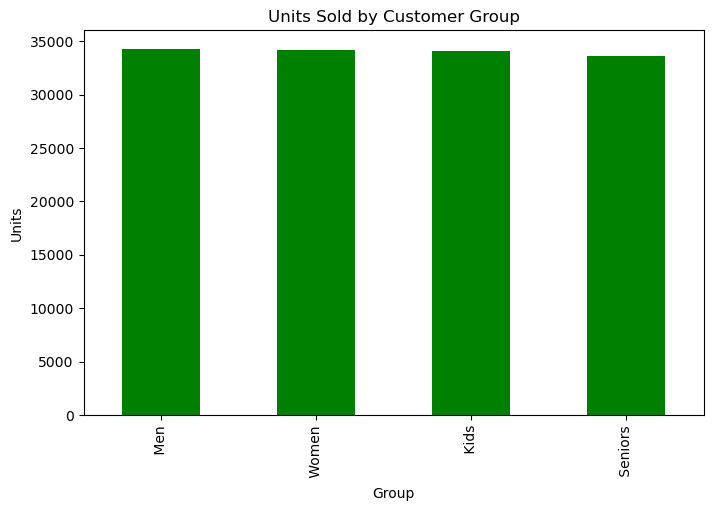

In [43]:
group_units = df.groupby("Group")["Unit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
group_units.plot(kind="bar", color= "green")
plt.title("Units Sold by Customer Group")
plt.ylabel("Units")
plt.show()

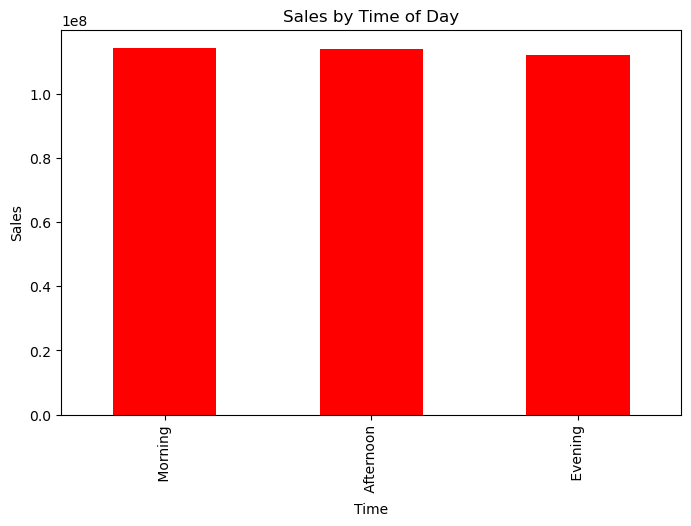

In [44]:
#Step 3: Time-of-Day Analysis

time_sales= df.groupby("Time")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
time_sales.plot(kind="bar", color="red")
plt.title("Sales by Time of Day")
plt.ylabel("Sales")
plt.show()

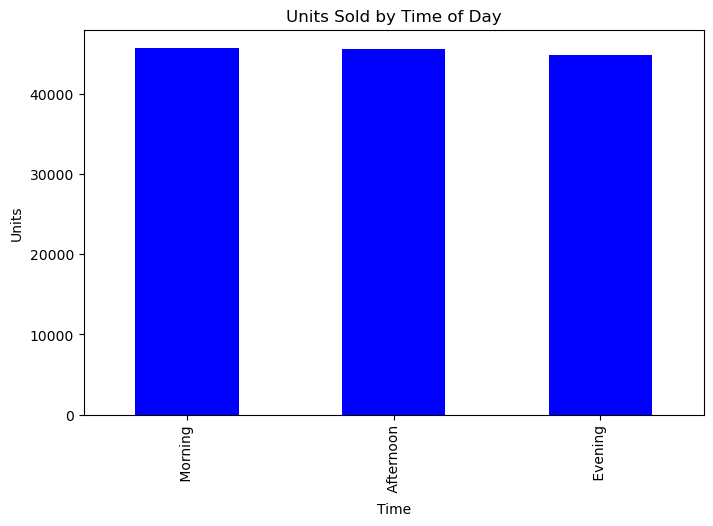

In [45]:
time_units= df.groupby("Time")["Unit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
time_units.plot(kind="bar", color="blue")
plt.title("Units Sold by Time of Day")
plt.ylabel("Units")
plt.show()

In [46]:
time_units.head()

Time
Morning      45683
Afternoon    45603
Evening      44835
Name: Unit, dtype: int64

In [47]:
#Best and Worst State by Sales

best_state=state_sales.idxmax()
worst_state=state_sales.idxmin()

print("best_state = ",best_state)
print("worst_state = ",worst_state)

best_state =  KY
worst_state =   WA


In [48]:
# Best and Worst Group (By sales)

best_group= group_sales.idxmax()
worst_group = group_sales.idxmin()

print("best_group=", best_group)
print("worst_group=", worst_group)

best_group=  Men
worst_group=  Seniors


In [49]:
# Best & Worst Time of Day (by sales)

best_time=time_sales.idxmax()
worst_time=time_sales.idxmin()

print("best_time=", best_time)
print("worst_time=", worst_time)

best_time=  Morning
worst_time=  Evening
